In [3]:
# 0. Install the missing Ultralytics library quietly
!pip install -q ultralytics

import os
import glob
import yaml
import kagglehub
from ultralytics import YOLO

# ==========================================
# 1. DOWNLOAD AND DYNAMICALLY SCAN DATASET
# ==========================================
print("📥 Downloading/Accessing dataset via kagglehub...")
cache_dir = kagglehub.dataset_download("sujaymann/car-number-plate-dataset-yolo-format")
print(f"✅ Dataset located at: {cache_dir}")

# Dynamically searching for 'images' folders inside the extracted structure
images_dirs = glob.glob(os.path.join(cache_dir, "**", "images"), recursive=True)

train_images_path = None
val_images_path = None

for d in images_dirs:
    if "train" in d.lower():
        train_images_path = d
    elif "valid" in d.lower() or "test" in d.lower():
        val_images_path = d

# Fallback mechanism if folders are named differently
if not train_images_path or not val_images_path:
    print("⚠️ Auto-matching folders failed. Mapping directly using root structure...")
    # Checking for specific root folders inside this particular dataset
    possible_train = os.path.join(cache_dir, "train")
    possible_val = os.path.join(cache_dir, "valid") if os.path.exists(os.path.join(cache_dir, "valid")) else os.path.join(cache_dir, "test")

    train_images_path = possible_train if not os.path.isdir(os.path.join(possible_train, "images")) else os.path.join(possible_train, "images")
    val_images_path = possible_val if not os.path.isdir(os.path.join(possible_val, "images")) else os.path.join(possible_val, "images")

print(f"📁 Verified Train Path: {train_images_path}")
print(f"📁 Verified Val Path:   {val_images_path}")

# ==========================================
# 2. CREATE CUSTOM data.yaml WITH EXACT PATHS
# ==========================================
yaml_data = {
    'train': train_images_path,
    'val': val_images_path,
    'nc': 1,
    'names': ['license_plate']
}

yaml_file_path = '/content/dataset.yaml'

with open(yaml_file_path, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"📝 Custom YOLO configuration file updated at: {yaml_file_path}")

# ==========================================
# 3. LOAD PRE-TRAINED YOLO MODEL
# ==========================================
model = YOLO('yolov8n.pt')

# ==========================================
# 4. START TRAINING (Flat Green Progress Bar)
# ==========================================
print("\n🚀 Starting YOLOv8 Training for License Plate Detection...")

results = model.train(
    data=yaml_file_path,
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project='LicensePlate_Project',
    name='yolov8_detector'
)

print("\n🎉 Training completed successfully!")


📥 Downloading/Accessing dataset via kagglehub...
Using Colab cache for faster access to the 'car-number-plate-dataset-yolo-format' dataset.
✅ Dataset located at: /kaggle/input/car-number-plate-dataset-yolo-format
📁 Verified Train Path: /kaggle/input/car-number-plate-dataset-yolo-format/License-Plate-Data/train/images
📁 Verified Val Path:   /kaggle/input/car-number-plate-dataset-yolo-format/License-Plate-Data/test/images
📝 Custom YOLO configuration file updated at: /content/dataset.yaml

🚀 Starting YOLOv8 Training for License Plate Detection...
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1

🎬 Found 87 holdout test images. Processing batch inference...


Predicting: 100% |██████████| 87/87 [00:05<00:00, 16.33it/s]
/tmp/ipykernel_603/1676653250.py:53: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.92])



📊 Generating Premium Dashboard Grid for Top 9 Test Results...



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


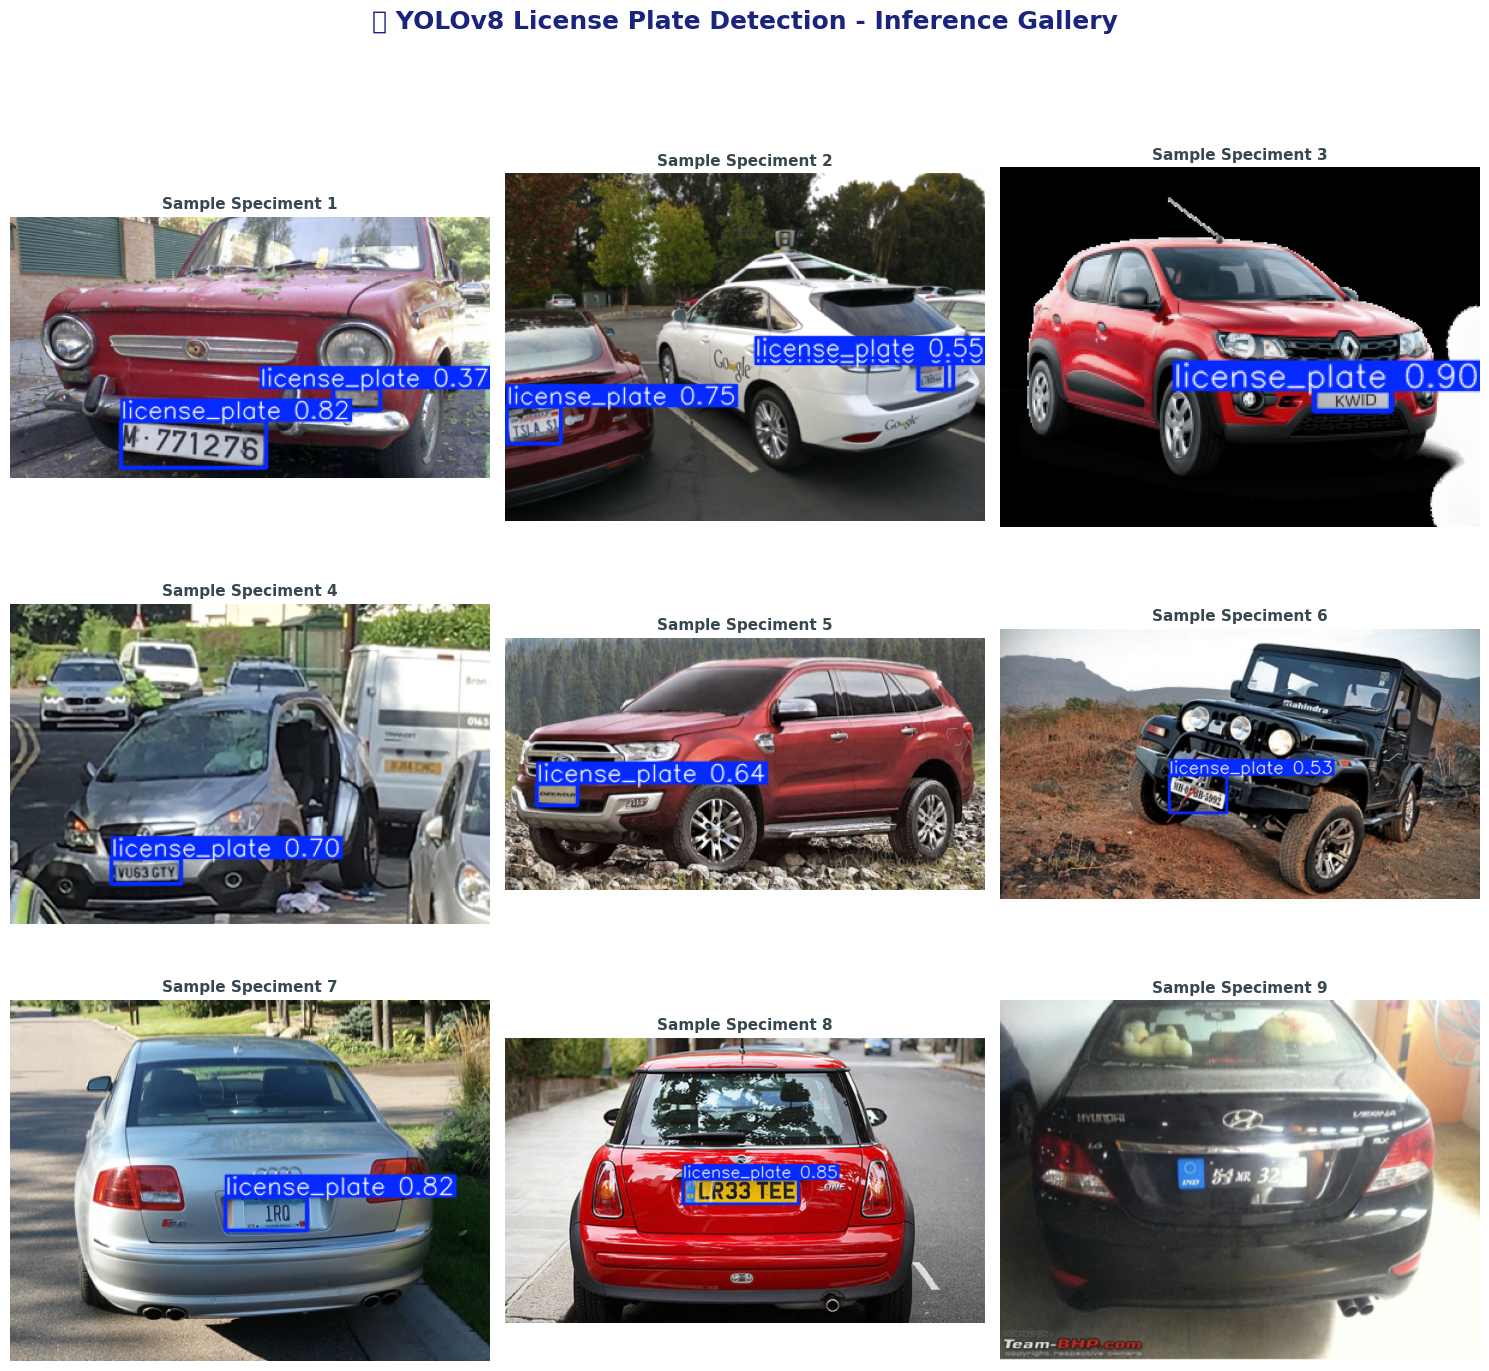

In [4]:
import os
import cv2
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

# ==========================================
# 1. LOAD BEST TRAINED MODEL
# ==========================================
best_model_path = '/content/runs/detect/LicensePlate_Project/yolov8_detector-2/weights/best.pt'
trained_model = YOLO(best_model_path)

# ==========================================
# 2. BATCH INFERENCE ON ALL TEST IMAGES
# ==========================================
test_image_dir = '/kaggle/input/car-number-plate-dataset-yolo-format/License-Plate-Data/test/images'
test_images = glob.glob(os.path.join(test_image_dir, "*.png"))

print(f"🎬 Found {len(test_images)} holdout test images. Processing batch inference...")

# Flat-bar progress styling matching Hugging Face structure
PBAR_FORMAT = "{desc}: {percentage:3.0f}% |{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"

processed_results = []

# Loop through all test files with a clean flat green bar
for img_path in tqdm(test_images, desc="Predicting", bar_format=PBAR_FORMAT, colour="#388e3c"):
    # conf=0.25 keeps a professional precision balance
    results = trained_model.predict(source=img_path, conf=0.25, verbose=False)
    for result in results:
        # Generate the bounding box plotted frame
        res_plotted = result.plot()
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        processed_results.append(res_rgb)

# ==========================================
# 3. PREMIUM GRID VISUALIZATION (Top 9 Samples)
# ==========================================
print("\n📊 Generating Premium Dashboard Grid for Top 9 Test Results...\n")

# Setting up a highly polished 3x3 plotting framework
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle("🏆 YOLOv8 License Plate Detection - Inference Gallery", fontsize=18, fontweight='bold', color='#1a237e', y=0.95)

# Rendering grid elements tightly to preserve aspect symmetry
for i, ax in enumerate(axes.flat):
    if i < len(processed_results):
        ax.imshow(processed_results[i])
        ax.set_title(f"Sample Speciment {i+1}", fontsize=11, fontweight='semibold', color='#37474f')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
